In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv("/content/train-test.csv")
val = pd.read_csv("/content/validation.csv")
dec = pd.read_csv("/content/december-chart-inputs.csv")
template = pd.read_csv("/content/validation-predictions-template.csv")

In [3]:
train.shape, train.dtypes

((48000, 14),
 load_id          object
 pickup           object
 delivery         object
 pickup_lat      float64
 pickup_lon      float64
 delivery_lat    float64
 delivery_lon    float64
 distance        float64
 equipment        object
 weight          float64
 date             object
 market_index    float64
 quote_signal    float64
 posted_rate     float64
 dtype: object)

In [4]:
train.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [15]:
val.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,165


In [17]:
print("train weight null %:", train["weight"].isna().mean())
print("val weight null %:", val["weight"].isna().mean())
print("train market_index null %:", train["market_index"].isna().mean())
print("val market_index null %:", val["market_index"].isna().mean())

train weight null %: 0.00625
val weight null %: 0.01375
train market_index null %: 0.007791666666666666
val market_index null %: 0.02075


<Axes: xlabel='date'>

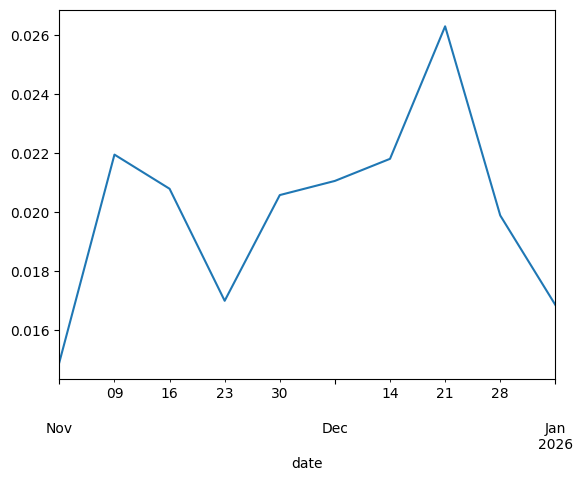

In [19]:
val['date'] = pd.to_datetime(val['date'])
val.set_index('date')['market_index'].isna().resample('W').mean().plot()

In [20]:
val["date"].min(), val["date"].max()

(Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [5]:
train["date"].min(), train["date"].max()

('2025-01-01', '2025-10-31')

In [6]:
train["posted_rate"].describe()

,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


In [7]:
train[['market_index', 'quote_signal']].corr()

,market_index,quote_signal
market_index,1.000000,-0.067827
quote_signal,-0.067827,1.000000


In [8]:
train[["market_index","quote_signal","posted_rate"]].corr()

,market_index,quote_signal,posted_rate
market_index,1.000000,-0.067827,0.034165
quote_signal,-0.067827,1.000000,-0.039858
posted_rate,0.034165,-0.039858,1.000000


In [9]:
train[train['weight'].isna()]['posted_rate']

,posted_rate
323,5430.07
648,1178.03
694,1022.13
732,4991.60
911,1643.25
...,...
47473,1745.58
47478,4115.49
47582,3789.30
47700,1262.99


In [11]:
train[train[['market_index', 'weight']].isna().any(axis=1)]['posted_rate']

,posted_rate
116,1271.10
226,2743.13
311,5568.57
323,5430.07
511,2786.63
...,...
47582,3789.30
47612,403.88
47700,1262.99
47808,1819.36


In [12]:
train[train[['market_index', 'weight']].isna().all(axis=1)]['posted_rate']

,posted_rate
28995,1156.87
